# 03. Outliers & Data Transformation
## 📚 Learning Objectives

By completing this notebook, you will:
- Detect outliers and apply transformations
- Use scaling and encoding where relevant
- Interpret cleaned data and summaries

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2, lesson 02 "Missing Values & Duplicates" — missing values are the obvious defect; outliers are the one that survives a clean dataset check.

**Used later in:** Course 05 — Unit 3, whose box plots and distribution charts are how outliers are usually spotted first.

---


## 🎯 The case: the ozone hole that nobody would believe

NASA's **Nimbus-7 satellite** carried the Total Ozone Mapping Spectrometer and had been
measuring atmospheric ozone since 1978. Its processing software did what every sensible
pipeline does: values far outside the expected range were flagged as suspect rather than
published, because instruments fail and a wild reading is usually a broken detector, not a
broken sky.

Over Antarctica in the early 1980s, the readings went far outside the expected range.
NASA checked them against the other ozone data available at the time, which showed roughly
300 Dobson units, concluded the instrument was misbehaving, and did not report the
anomaly. Then in May 1985 **Farman, Gardiner and Shanklin** of the British Antarctic
Survey published ground-based measurements from Halley Bay in *Nature* (315, 207–210)
showing a catastrophic springtime ozone loss. NASA reprocessed the satellite archive and
confirmed it — Stolarski et al., *"Nimbus 7 satellite measurements of the springtime
Antarctic ozone decrease"*, Nature 322, 808–811 (1986). The satellite had been recording
the ozone hole for years.

Be precise about what went wrong, because the popular retelling is not accurate. Richard
McPeters, who headed NASA's Ozone Processing Team, has stated that the software did *not*
throw the low values away — it recorded and reported them, flagged for checking. What was
missing was a trustworthy independent measurement to check them against, and anyone willing
to publish a number that looked impossible.

**What goes wrong without this lesson.** An outlier rule is a decision about what you are
willing to believe, applied automatically, at scale, to data nobody will look at again. You
are about to see the same tension in miniature: the IQR rule flags **114 of 889** Titanic
fares, and **102 of those 114 are first-class passengers**. "Outlier" there does not mean
"wrong". It means "rich" — and deleting them would delete the strongest signal in the
dataset (first-class survival 63% against third-class 24%).


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Solving the Problem from Example 2

**Remember the dead end from Example 2?**
- We cleaned missing values and duplicates successfully
- But we discovered the cleaned data still had outliers
- Outliers were skewing our statistics and affecting analysis

**This notebook solves that problem!**
- We'll learn how to **detect** outliers using statistical methods
- We'll learn **strategies** for handling outliers (remove, transform, cap)
- We'll learn **data transformation** techniques (normalization, scaling)
- We'll **complete the data cleaning process** so we have truly clean data!

**This solves the outlier problem from Example 2!**

---

## The Story: Refining Your Ingredients

Imagine you're preparing ingredients. **After** cleaning, you need to check for any bad 
items (outliers) and cut them to same sizes (transformation). **After** refinement, 
everything is perfect for cooking!

Same with data: **After** removing missing values and duplicates, we detect outliers 
(extreme values) and transform data (normalize scales). **After** refinement, data is 
perfect for analysis!

---

## Why Outliers & Transformation Matter

These techniques are essential because:
- **Outliers**: Skew statistics and predictions - must be handled
- **Transformation**: Normalize scales so features are comparable
- **Model Performance**: Clean, transformed data = better models
- **Analysis Accuracy**: Outliers can completely change results

## Learning Objectives
1. Detect outliers using multiple methods (IQR, Z-score, visualization)
2. Handle outliers (remove, cap, or transform)
3. Apply data transformations (log, square root, normalization)
4. Understand when to use each transformation
5. Prepare data for machine learning models


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Data with outliers
- pandas, numpy

**Outputs:** What you'll see when you run the cells

- Transformed data
- Plots, stats, printed summaries

---

In [1]:
# WHAT: Import analysis libraries plus scipy.stats (Z-scores) and sklearn scalers.
# WHY: Outlier detection is statistics (scipy) and rescaling is preprocessing (sklearn) - the two halves of this lesson.

# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # Statistical functions (Z-score calculation)
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # Data transformation tools

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Data manipulation and analysis")
print("   - numpy: Numerical operations (log/sqrt transforms)")
print("   - matplotlib/seaborn: Visualization")
print("   - scipy.stats: Statistical functions (Z-scores, etc.)")
print("   - sklearn.preprocessing: Data transformation tools (MinMax, StandardScaler)")

print("\n" + "=" * 70)
print("Example 3: Outliers & Data Transformation")
print("=" * 70)
print("\n📚 Prerequisites: Example 2 completed, clean data without missing values")
print("🔗 This is the THIRD example in Unit 2 (of 8) - the outlier-handling step")
print("🎯 Goal: Master outlier detection and data transformation techniques\n")


✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Data manipulation and analysis
   - numpy: Numerical operations (log/sqrt transforms)
   - matplotlib/seaborn: Visualization
   - scipy.stats: Statistical functions (Z-scores, etc.)
   - sklearn.preprocessing: Data transformation tools (MinMax, StandardScaler)

Example 3: Outliers & Data Transformation

📚 Prerequisites: Example 2 completed, clean data without missing values
🔗 This is the THIRD example in Unit 2 (of 8) - the outlier-handling step
🎯 Goal: Master outlier detection and data transformation techniques



## Part 1: Real Data That Already Contains Outliers

**BEFORE**: We need to practice outlier detection, and we need data with outliers.

**AFTER**: We'll use the Titanic `Fare` column — where the most expensive ticket cost
35 times the median one, and every one of those extremes is a real purchase!

**Why this matters**: Planted outliers are easy — you already know the answer. Real
outliers force the harder question: *is this an error, or is it the truth?*


## Step 1: Loading Data With Real Outliers

**BEFORE**: We have the cleaned manifest from Example 2.

**AFTER**: We look hard at its `Fare` column, which is violently right-skewed.


In [2]:
# WHAT: Load the real manifest and take a first look at the Fare column's shape.
# WHY: Fare is genuinely skewed - a handful of first-class passengers paid orders of magnitude more than everyone else.

print("\n1. Loading Data With Real Outliers")
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'
df = pd.read_csv(DATA_DIR + 'titanic.csv')

# Impute Age within (Pclass, Sex) groups exactly as Example 2 concluded, so this
# notebook starts from the cleaned state the previous one ended in.
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda s: s.fillna(s.median()))
df = df.drop(columns=['Cabin']).dropna(subset=['Embarked'])

print(f"✓ Loaded {len(df)} passengers, {df.shape[1]} columns, "
      f"{df.isnull().sum().sum()} missing values remaining")
print("\nThe Fare column:")
print(df['Fare'].describe().round(2).to_string())
print(f"\n  Median fare:  {df['Fare'].median():.2f}")
print(f"  Mean fare:    {df['Fare'].mean():.2f}  (pulled up by the top end)")
print(f"  Maximum fare: {df['Fare'].max():.2f}")
print(f"  Skewness:     {df['Fare'].skew():.2f}  (0 would be symmetric)")
print(f"  Passengers who paid exactly 0: {(df['Fare'] == 0).sum()}"
      " - crew, guests and staff travelled free")
print("\n✓ No outliers were added. Everything extreme below is a real ticket price.")



1. Loading Data With Real Outliers
----------------------------------------------------------------------
✓ Loaded 889 passengers, 11 columns, 0 missing values remaining

The Fare column:
count    889.00
mean      32.10
std       49.70
min        0.00
25%        7.90
50%       14.45
75%       31.00
max      512.33

  Median fare:  14.45
  Mean fare:    32.10  (pulled up by the top end)
  Maximum fare: 512.33
  Skewness:     4.80  (0 would be symmetric)
  Passengers who paid exactly 0: 15 - crew, guests and staff travelled free

✓ No outliers were added. Everything extreme below is a real ticket price.


## Part 2: Detecting Outliers - Z-Score Method

**BEFORE**: You have data but don't know which values are outliers.

**AFTER**: You'll use Z-scores to identify values that are too far from the mean!

**Why Z-score?** It's a statistical method that measures how many standard deviations a value is from the mean!

## Step 2: Z-Score Method

**BEFORE**: Outliers are hidden in our data.

**AFTER**: We'll use Z-scores to detect values that are more than 3 standard deviations away!

In [3]:
# WHAT: Detect outliers with the Z-score rule (|z| > 3).
# WHY: Z-scores measure distance from the mean in standard deviations - a natural cutoff when data is roughly normal.

print("\n\n2. Outlier Detection Z Score Method")
print("-" * 70)
# Calculate Z-scores
z_scores = np.abs(stats.zscore(df['Fare']))
threshold = 3
outliers_zscore = df[z_scores > threshold]
print(f"Outliers detected (Z-score > {threshold}): {len(outliers_zscore)}")
print(f"   Outliers detected (Z-score > {threshold}): {len(outliers_zscore)}")
print(f"\nThe passengers the Z-score rule flagged:")
print(outliers_zscore[['Name', 'Pclass', 'Fare']].head().to_string(index=False))
print("\n⚠ Z-score has a blind spot on skewed data: the mean and standard deviation")
print("   it relies on are themselves inflated BY these extreme values. That is why")
print("   it flags far fewer points than the IQR rule below.")




2. Outlier Detection Z Score Method
----------------------------------------------------------------------
Outliers detected (Z-score > 3): 20
   Outliers detected (Z-score > 3): 20

The passengers the Z-score rule flagged:
                                           Name  Pclass     Fare
                 Fortune, Mr. Charles Alexander       1 263.0000
                     Fortune, Miss. Mabel Helen       1 263.0000
                       Baxter, Mr. Quigg Edmond       1 247.5208
                               Ward, Miss. Anna       1 512.3292
Baxter, Mrs. James (Helene DeLaudeniere Chaput)       1 247.5208

⚠ Z-score has a blind spot on skewed data: the mean and standard deviation
   it relies on are themselves inflated BY these extreme values. That is why
   it flags far fewer points than the IQR rule below.


## Part 3: Detecting Outliers - IQR Method

**BEFORE**: Z-score works, but IQR is another powerful method.

**AFTER**: You'll use the Interquartile Range method to detect outliers!

**Why IQR?** It's robust to extreme values and works well for skewed distributions!

## Step 3: IQR Method

**BEFORE**: We detected outliers with Z-score, but want to compare methods.

**AFTER**: We'll use IQR (Interquartile Range) to detect outliers differently!

In [4]:
# WHAT: Detect outliers with the IQR rule (outside Q1-1.5*IQR .. Q3+1.5*IQR).
# WHY: Quartiles resist the pull of the outliers themselves, so IQR works even on skewed data - it is the boxplot's rule.

print("\n\n3. Outlier Detection IQR Method")
print("-" * 70)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Outliers detected (IQR method): {len(outliers_iqr)}"
      f" ({len(outliers_iqr) / len(df) * 100:.1f}% of passengers)")
print(f"Z-score flagged {len(outliers_zscore)}, IQR flagged {len(outliers_iqr)}"
      " - on the SAME column.")
print("\n💡 Which is right? Neither, automatically. The IQR rule uses quartiles,")
print("   which the extremes cannot drag around, so it is the safer default on")
print("   skewed money columns. But look at who it flagged:")
print(outliers_iqr['Pclass'].value_counts().sort_index().to_string())
print("   Almost all of them are 1st class. 'Outlier' here means 'rich', not 'wrong'.")
print("   Deleting these rows would delete the wealthy - and with them the")
print(f"   strongest signal in the data (1st class survival"
      f" {df[df['Pclass'] == 1]['Survived'].mean():.0%} vs 3rd class"
      f" {df[df['Pclass'] == 3]['Survived'].mean():.0%}).")




3. Outlier Detection IQR Method
----------------------------------------------------------------------
Q1: 7.90, Q3: 31.00, IQR: 23.10
Lower bound: -26.76, Upper bound: 65.66
Outliers detected (IQR method): 114 (12.8% of passengers)
Z-score flagged 20, IQR flagged 114 - on the SAME column.

💡 Which is right? Neither, automatically. The IQR rule uses quartiles,
   which the extremes cannot drag around, so it is the safer default on
   skewed money columns. But look at who it flagged:
Pclass
1    102
2      5
3      7
   Almost all of them are 1st class. 'Outlier' here means 'rich', not 'wrong'.
   Deleting these rows would delete the wealthy - and with them the
   strongest signal in the data (1st class survival 63% vs 3rd class 24%).


## 💬 Discuss

On the **same column**, the Z-score rule flagged **20** fares and the IQR rule flagged
**114** — 12.8% of passengers, of whom **102 were first class, 5 second, 7 third**. The
most expensive ticket, £512.33, was 35× the median of £14.45. None of these are errors.

1. Two defensible methods, one column, a 5.7× difference in verdict. Explain *why* the
   Z-score found fewer, using the numbers printed above (mean 32.10, std 49.70). Which
   would you present to a client, and how would you answer "so which one is right?"
2. Because almost every flagged fare is first class, "remove outliers" and "remove the
   wealthy passengers" are the same operation on this dataset. Suppose the task is
   predicting survival. Argue for removing them anyway — then argue against. What fact
   about the *goal*, not the data, decides it?
3. **15 passengers have a fare of exactly £0.00** — crew, guests and staff who travelled
   free. They are not outliers by either rule, because they are at the bottom of a
   right-skewed column. Should a zero be treated as a value, a missing marker, or its own
   category? What would you check in the original records before deciding?


## Part 4: Visualizing Outliers

**BEFORE**: You have numbers but can't see outliers clearly.

**AFTER**: You'll see visual plots that make outliers obvious!

**Why this matters**: Visualizations help you understand outlier patterns!

## Step 4: Visualizing Outliers

**BEFORE**: Outliers are detected but hard to visualize.

**AFTER**: We'll create multiple plots to see outliers clearly!



4. Visualizing Outliers
----------------------------------------------------------------------


✓ Outlier visualization saved


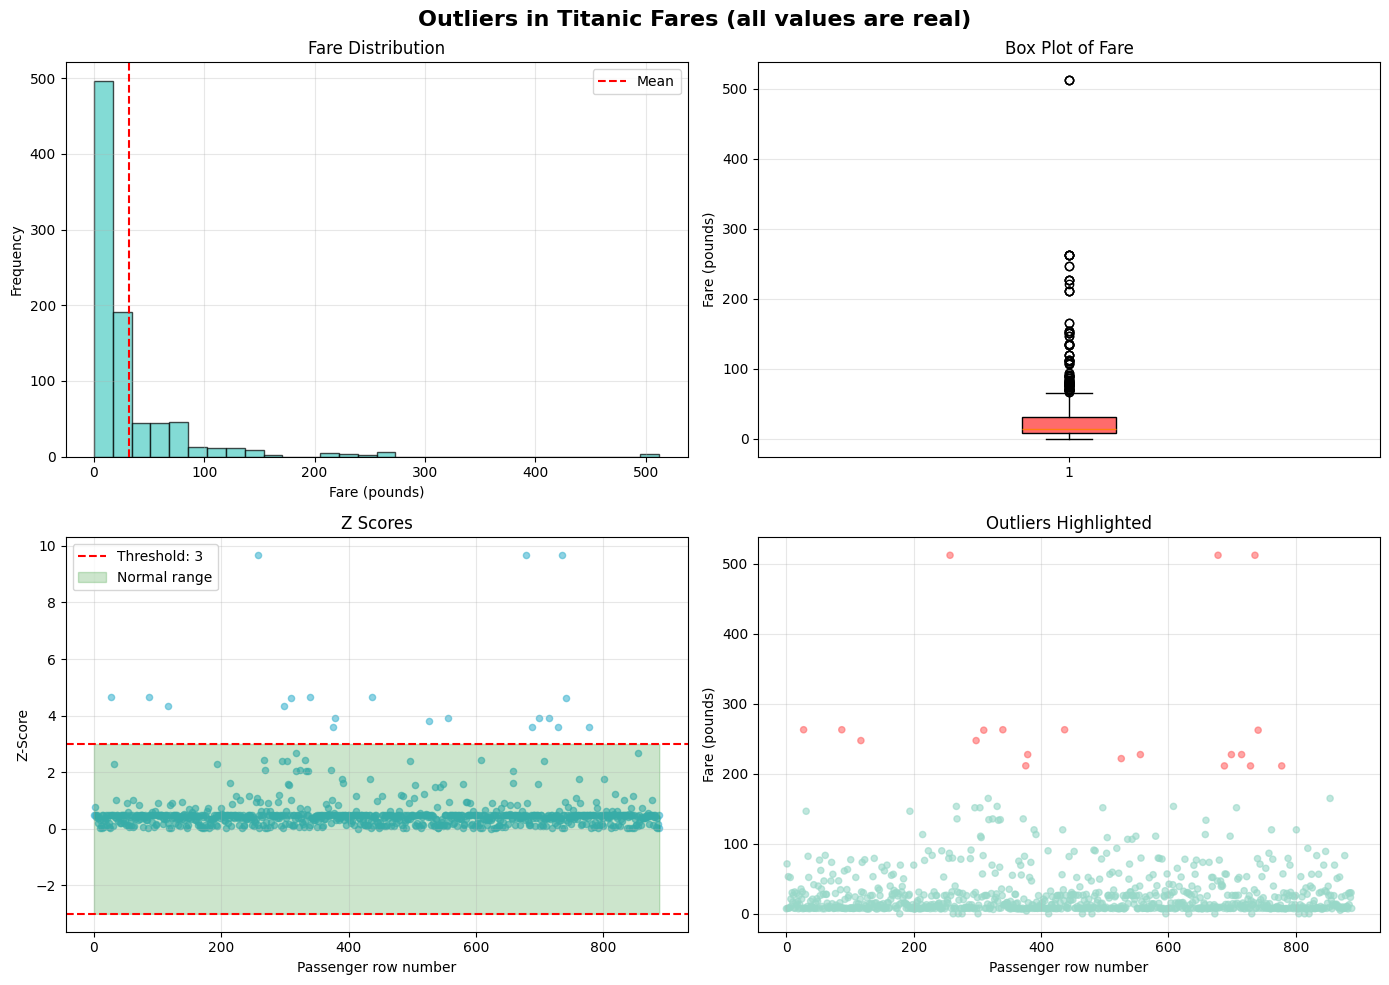

In [5]:
# WHAT: Visualize the real Fare outliers four ways (histogram, box plot, Z-scores, highlighted scatter).
# WHY: The statistics give you counts; the pictures show you the SHAPE that produced those counts.
print("\n\n4. Visualizing Outliers")
print("-" * 70)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Outliers in Titanic Fares (all values are real)', fontsize=16, weight='bold')
# Plot 1: Histogram
axes[0, 0].hist(df['Fare'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['Fare'].mean(), color='r', linestyle='--', label='Mean')
axes[0, 0].set_title('Fare Distribution')
axes[0, 0].set_xlabel('Fare (pounds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# Plot 2: Box plot
bp = axes[0, 1].boxplot(df['Fare'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#FF6B6B')
axes[0, 1].set_title('Box Plot of Fare')
axes[0, 1].set_ylabel('Fare (pounds)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Plot 3: Z-score
axes[1, 0].scatter(range(len(df)), z_scores, alpha=0.6, color='#45B7D1', s=20)
axes[1, 0].axhline(y=threshold, color='r', linestyle='--', label=f'Threshold: {threshold}')
axes[1, 0].axhline(y=-threshold, color='r', linestyle='--')
axes[1, 0].fill_between(range(len(df)), -threshold, threshold, alpha=0.2, color='green', label='Normal range')
axes[1, 0].set_title('Z Scores')
axes[1, 0].set_xlabel('Passenger row number')
axes[1, 0].set_ylabel('Z-Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# Plot 4: Scatter with outliers highlighted
colors = ['#FF6B6B' if z > threshold else '#98D8C8' for z in z_scores]
axes[1, 1].scatter(range(len(df)), df['Fare'], c=colors, alpha=0.6, s=20)
axes[1, 1].set_title('Outliers Highlighted')
axes[1, 1].set_xlabel('Passenger row number')
axes[1, 1].set_ylabel('Fare (pounds)')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outliers_detection.png', dpi=300, bbox_inches='tight')
print("✓ Outlier visualization saved")


## Part 5: Data Transformation - Normalization

**BEFORE**: You have outliers detected but data is on different scales.

**AFTER**: You'll normalize data to a 0-1 range!

**Why normalization?** Makes all features comparable and helps ML models learn better!

## Step 5: Min-Max Normalization

**BEFORE**: Data values range widely and aren't comparable.

**AFTER**: We'll transform data to 0-1 range for better comparability!

In [6]:
# WHAT: Rescale 'Fare' to the 0-1 range with MinMaxScaler.
# WHY: Distance-based models (kNN, neural nets) need comparable feature ranges; min-max keeps the shape but bounds the range.

print("\n\n5. Data Transformation Normalization")
print("-" * 70)
# Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_normalized = df.copy()
df_normalized['fare_normalized'] = scaler_minmax.fit_transform(df[['Fare']])
print("Min Max Normalization:")
print(f"Original range: [{df['Fare'].min():.2f}, {df['Fare'].max():.2f}]")
print(f"Normalized range: [{df_normalized['fare_normalized'].min():.2f}, {df_normalized['fare_normalized'].max():.2f}]")
print(f"\n⚠ Min-max is defined by the MINIMUM and MAXIMUM - i.e. by the two most")
print("   extreme values in the column. Here the single 512-pound ticket sets the")
print(f"   top of the scale, so the median fare lands at only"
      f" {df_normalized['fare_normalized'].median():.3f}.")
print("   Half the passengers are squashed into the bottom 3% of the range.")




5. Data Transformation Normalization
----------------------------------------------------------------------
Min Max Normalization:
Original range: [0.00, 512.33]
Normalized range: [0.00, 1.00]

⚠ Min-max is defined by the MINIMUM and MAXIMUM - i.e. by the two most
   extreme values in the column. Here the single 512-pound ticket sets the
   top of the scale, so the median fare lands at only 0.028.
   Half the passengers are squashed into the bottom 3% of the range.


## Part 6: Data Transformation - Standardization

**BEFORE**: You normalized data, but standardization is another important method.

**AFTER**: You'll standardize data to have mean=0 and std=1!

**Why standardization?** Better for some ML algorithms (like neural networks)!

## Step 6: Standardization (Z-Score)

**BEFORE**: Data is normalized but we want mean=0, std=1.

**AFTER**: We'll standardize data to standard normal distribution!

In [7]:
# WHAT: Standardize 'Fare' to mean 0 and std 1 with StandardScaler.
# WHY: Standardization is the default for linear models and PCA - features become comparable without needing a bounded range.

print("\n\n6. Data Transformation Standardization")
print("-" * 70)
scaler_standard = StandardScaler()
df_standardized = df.copy()
df_standardized['fare_standardized'] = scaler_standard.fit_transform(df[['Fare']])
print("Standardization (Z score):")
print(f"Original mean: {df['Fare'].mean():.2f}, std: {df['Fare'].std():.2f}")
print(f"Standardized mean: {df_standardized['fare_standardized'].mean():.4f}, std: {df_standardized['fare_standardized'].std():.4f}")
print(f"\n   Standardizing does NOT remove the skew: max is still"
      f" {df_standardized['fare_standardized'].max():.2f} standard deviations out.")
print("   Rescaling moves the axis; it does not change the shape.")




6. Data Transformation Standardization
----------------------------------------------------------------------
Standardization (Z score):
Original mean: 32.10, std: 49.70
Standardized mean: 0.0000, std: 1.0006

   Standardizing does NOT remove the skew: max is still 9.67 standard deviations out.
   Rescaling moves the axis; it does not change the shape.


## Part 6b: Log and Square-Root Transforms

**BEFORE**: Scaling changes the range, but a skewed shape stays skewed.

**AFTER**: Log and square-root transforms compress the long right tail —
they change the *shape* of the distribution, not just its scale.



6b. Log and Square-Root Transforms
----------------------------------------------------------------------
Passengers with a recorded fare of exactly 0: 15
   -> np.log() would give -inf for those rows, so we use np.log1p().

Skewness of original 'Fare':          4.801
Skewness after log1p transform:       0.400
Skewness after square-root transform: 2.100

→ Both compress the high fares; log compresses more strongly than sqrt
→ Use them on right-skewed data (incomes, prices, counts) before modeling
→ Note the trade: the transformed column is no longer in pounds, so every
  coefficient or plot built on it needs back-transforming to explain.


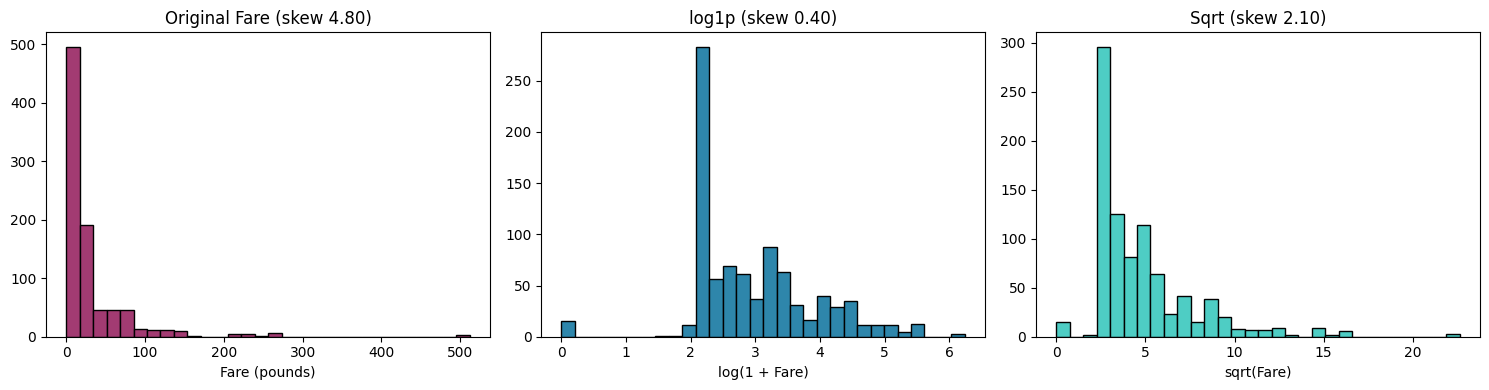

✓ Distribution shapes compared before/after transformation


In [8]:
# WHAT: Apply log and square-root transforms and compare skewness before and after.
# WHY: Skewed data breaks many model assumptions; these transforms compress the long right tail toward symmetry.

print("\n\n6b. Log and Square-Root Transforms")
print("-" * 70)

skew_before = df['Fare'].skew()

# np.log would return -inf for the passengers who paid 0 - and there really are some.
# np.log1p computes log(1 + x), which handles zeros correctly. This is not a
# technicality: it is why log1p exists.
n_zero = int((df['Fare'] == 0).sum())
print(f"Passengers with a recorded fare of exactly 0: {n_zero}")
print("   -> np.log() would give -inf for those rows, so we use np.log1p().")

log_transformed = np.log1p(df['Fare'])
sqrt_transformed = np.sqrt(df['Fare'])

print(f"\nSkewness of original 'Fare':          {skew_before:.3f}")
print(f"Skewness after log1p transform:       {log_transformed.skew():.3f}")
print(f"Skewness after square-root transform: {sqrt_transformed.skew():.3f}")
print("\n→ Both compress the high fares; log compresses more strongly than sqrt")
print("→ Use them on right-skewed data (incomes, prices, counts) before modeling")
print("→ Note the trade: the transformed column is no longer in pounds, so every")
print("  coefficient or plot built on it needs back-transforming to explain.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['Fare'], bins=30, color='#A23B72', edgecolor='black')
axes[0].set_title(f'Original Fare (skew {skew_before:.2f})')
axes[0].set_xlabel('Fare (pounds)')
axes[1].hist(log_transformed, bins=30, color='#2E86AB', edgecolor='black')
axes[1].set_title(f'log1p (skew {log_transformed.skew():.2f})')
axes[1].set_xlabel('log(1 + Fare)')
axes[2].hist(sqrt_transformed, bins=30, color='#4ECDC4', edgecolor='black')
axes[2].set_title(f'Sqrt (skew {sqrt_transformed.skew():.2f})')
axes[2].set_xlabel('sqrt(Fare)')
plt.tight_layout()
plt.show()
print("✓ Distribution shapes compared before/after transformation")


## 💬 Discuss

Measured above: min-max scaling put the **median fare at 0.028** — half the passengers
squeezed into the bottom 3% of the range, because one £512 ticket defines the top.
Standardizing left the maximum **9.67 standard deviations** out. Only `log1p` actually
changed the shape, dropping skewness from **4.801 to 0.400**.

1. Three transformations, and only one of them altered the distribution. State in one
   sentence the difference between *rescaling* and *reshaping*, then say which one a
   k-nearest-neighbours model needs and which one a linear regression's error assumption
   needs.
2. The log-transformed column is no longer in pounds. Your model predicts `log1p(Fare)`
   and you must report an average fare to a client. Naively exponentiating the mean of the
   logs gives you the *geometric* mean, which is lower than the arithmetic mean — for this
   column, substantially. Is that a bug or a more honest number? Defend a position.
3. Min-max scaling is fit on the training data's minimum and maximum. A new passenger
   arrives who paid £900. What does your scaler do, and what does the model see? Name the
   scaler you would have chosen instead and what you give up by choosing it.


## Part 7: Before/After Comparison

**BEFORE**: You have transformed data but can't see the difference.

**AFTER**: You'll visualize the transformation effects clearly!

**Why this matters**: See how transformations change your data distribution!

## Step 7: Transformation Comparison

**BEFORE**: We've transformed data but haven't compared results.

**AFTER**: We'll visualize original vs normalized vs standardized data!



7. Before/After Comparison
----------------------------------------------------------------------


✓ Transformation comparison saved


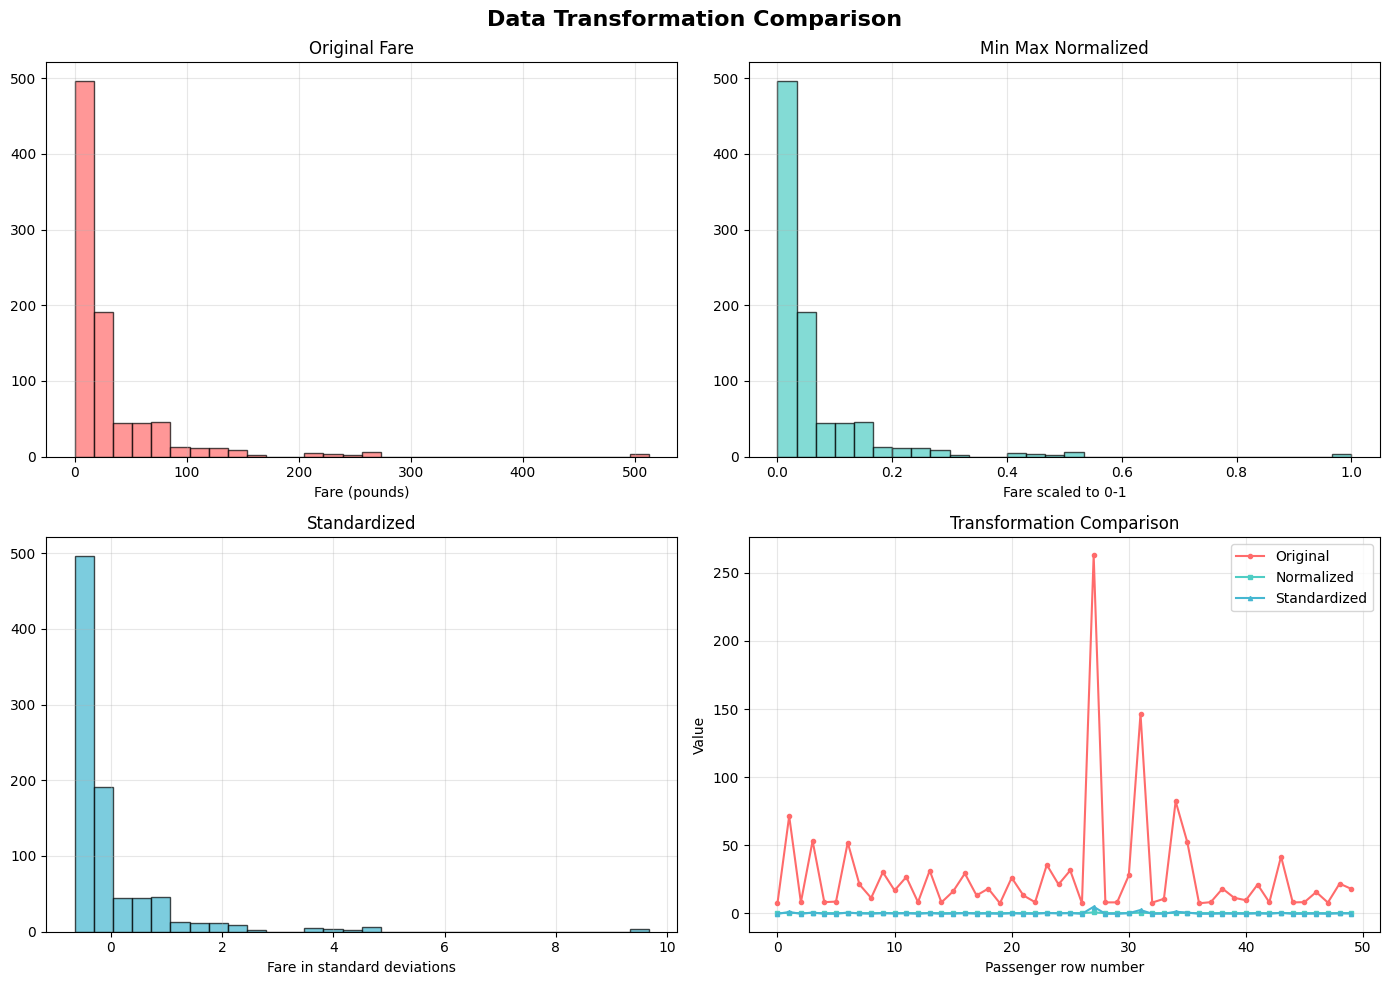

In [9]:
# WHAT: Compare the Fare distribution before vs after each transformation, side by side in one figure.
# WHY: Seeing all four panels at once makes clear that scaling moves the axis while log/sqrt reshape the distribution.
print("\n\n7. Before/After Comparison")
print("-" * 70)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Data Transformation Comparison', fontsize=16, weight='bold')
# Original
axes[0, 0].hist(df['Fare'], bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Original Fare')
axes[0, 0].set_xlabel('Fare (pounds)')
axes[0, 0].grid(True, alpha=0.3)
# Normalized
axes[0, 1].hist(df_normalized['fare_normalized'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Min Max Normalized')
axes[0, 1].set_xlabel('Fare scaled to 0-1')
axes[0, 1].grid(True, alpha=0.3)
# Standardized
axes[1, 0].hist(df_standardized['fare_standardized'], bins=30, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Standardized')
axes[1, 0].set_xlabel('Fare in standard deviations')
axes[1, 0].grid(True, alpha=0.3)
# Comparison
axes[1, 1].plot(df['Fare'].values[:50], label='Original', color='#FF6B6B', marker='o', markersize=3)
axes[1, 1].plot(df_normalized['fare_normalized'].values[:50], label='Normalized', color='#4ECDC4', marker='s', markersize=3)
axes[1, 1].plot(df_standardized['fare_standardized'].values[:50], label='Standardized', color='#45B7D1', marker='^', markersize=3)
axes[1, 1].set_title('Transformation Comparison')
axes[1, 1].set_xlabel('Passenger row number')
axes[1, 1].set_ylabel('Value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data_transformation.png', dpi=300, bbox_inches='tight')
print("✓ Transformation comparison saved")


## 🎯 Summary: What We Learned

## Final Summary

In [10]:
# WHAT: Print a recap of the outlier and transformation techniques.
# WHY: Together with Examples 1-2 this completes the standard cleaning pipeline - load, fix gaps/dupes, treat outliers, rescale.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this notebook:")
print("   - You had clean data but didn't know how to handle outliers")
print("   - You didn't know how to transform data for machine learning")
print("   - Your data had different scales that confused your models")

print("\n✅ AFTER this notebook:")
print("   - You can detect outliers using Z-score and IQR methods")
print("   - You can visualize outliers to understand their patterns")
print("   - You can normalize data (Min-Max scaling to 0-1)")
print("   - You can standardize data (mean=0, std=1)")
print("   - You understand when to use each transformation")
print("   - You know that a real outlier may be correct data, not an error")

print("\n📚 Key Concepts Covered:")
print("   1. Outlier Detection (Z-score method: values >3 std from mean)")
print("      - and why it under-detects on skewed columns")
print("   2. Outlier Detection (IQR method: values outside Q1-1.5*IQR to Q3+1.5*IQR)")
print("   3. Outlier Visualization (histograms, box plots, scatter plots)")
print("   4. Data Normalization (Min-Max: scales to 0-1 range)")
print("   5. Data Standardization (Z-score: mean=0, std=1)")

print("\n🔗 Where These Skills Fit:")
print("   - FINAL step in Unit 2 data cleaning (after missing values and duplicates)")
print("   - Essential BEFORE machine learning (models need transformed data)")
print("   - Critical for data visualization (outliers affect visualizations)")
print("   - Foundation for reliable analysis and modeling!")

print("\n➡️  Next Steps:")
print("   - Continue to Example 4: Feature Transformation (scale, encode)")
print("   - Then Example 5–6 (EDA), 7 (cuDF), 8 (feature extraction)")
print("   - Clean, transformed data is perfect for creating beautiful visualizations!")

print("\n" + "=" * 70)
plt.show()



🎯 SUMMARY: What We Learned

📋 BEFORE this notebook:
   - You had clean data but didn't know how to handle outliers
   - You didn't know how to transform data for machine learning
   - Your data had different scales that confused your models

✅ AFTER this notebook:
   - You can detect outliers using Z-score and IQR methods
   - You can visualize outliers to understand their patterns
   - You can normalize data (Min-Max scaling to 0-1)
   - You can standardize data (mean=0, std=1)
   - You understand when to use each transformation
   - You know that a real outlier may be correct data, not an error

📚 Key Concepts Covered:
   1. Outlier Detection (Z-score method: values >3 std from mean)
      - and why it under-detects on skewed columns
   2. Outlier Detection (IQR method: values outside Q1-1.5*IQR to Q3+1.5*IQR)
   3. Outlier Visualization (histograms, box plots, scatter plots)
   4. Data Normalization (Min-Max: scales to 0-1 range)
   5. Data Standardization (Z-score: mean=0, std=1)


## ⚠️ Where this breaks

- **"Outlier" is not a property of a number; it is a claim about a model.** Both rules
  here assume a single, roughly unimodal population. The Titanic `Fare` column is at least
  three populations — free passage, steerage, and first class — and the IQR rule is really
  reporting "these fares do not belong to the third-class distribution". Correct, and not
  what "outlier" is usually taken to mean.
- **Z-score is circular on skewed data, and this is measurable.** It uses the mean (32.10)
  and standard deviation (49.70), both of which are inflated *by* the extreme values it is
  supposed to catch. With skewness 4.80 it found 20 points where the quartile-based rule
  found 114. Use IQR, or a robust z-score built on the median and MAD, on any money-like
  column.
- **The 1.5×IQR fence is a convention, not a result.** Tukey chose it for roughly normal
  data, where it flags about 0.7% of points. Here it flags 12.8%. Report the fence you used
  and why; never present "outliers" as though the count were objective.
- **Deleting outliers is the option that is almost always wrong.** In fraud detection,
  intrusion detection, equipment failure and rare disease, **the outliers are the entire
  point** — the credit-card file in lesson 01 has 492 frauds in 284,807 transactions,
  every one of them an outlier by any rule you like. Delete first and you have deleted the
  signal.
- **The assumption that must hold for log/sqrt: strictly positive values.** 15 passengers
  paid exactly £0, so `np.log` gives `-inf` and the notebook uses `log1p` instead. Negative
  values (temperatures, profits, differences) rule out both; consider a Yeo–Johnson
  transform or none at all.
- **Cheaper alternative:** before transforming, ask whether your model cares. Tree-based
  models (decision trees, random forests, gradient boosting) are invariant to any monotone
  transformation of a feature — scaling and logging a fare column changes *nothing* about
  the splits they choose. Scaling matters for distance-based methods (kNN, k-means, SVM
  with RBF), for gradient descent convergence, and for PCA. Doing it everywhere "to be
  safe" costs you interpretability for free.

**The same tension elsewhere:** a hospital monitor whose alarm limits suppress the reading
that matters; a bank fraud filter tuned so tightly that the novel attack looks like noise;
a quality-control chart that discards the first sign of a failing machine. In each case
the filter was right on average and wrong exactly when it counted.


## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Chandola, V., Banerjee, A., & Kumar, V. (2009). *Anomaly Detection: A Survey*. ACM Computing Surveys, 41(3), 1-58. <https://doi.org/10.1145/1541880.1541882>
3. Han, S., Hu, X., Huang, H., Jiang, M., & Zhao, Y. (2022). *ADBench: Anomaly Detection Benchmark*. NeurIPS 2022 Datasets and Benchmarks. <https://arxiv.org/abs/2206.09426>
4. Röchner, P., Klüttermann, S., Kammler, K., Rothlauf, F., Müller, E., & Schlör, D. (2025). *We Need to Rethink Benchmarking in Anomaly Detection*. arXiv:2507.15584. <https://arxiv.org/abs/2507.15584>
5. Ding, X., Wen, H., Klüttermann, S., & Akoglu, L. (2026). *From Zero to Hero: Advancing Zero-Shot Foundation Models for Tabular Outlier Detection*. arXiv:2602.03018. <https://arxiv.org/abs/2602.03018>
